# 1.Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")

# 3.Explore the Dataset

### Display First Five Rows

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### Check Dataset shape

In [6]:
df.shape

(768, 7)

### Check Dataset information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


### statistical Summary

In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


### check missing values

In [9]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

### Remove Missing Values 

In [10]:
df = df.dropna()

### Check Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

### Remove duplicates:

In [17]:
df=df.drop_duplicates()

# 4.Exploratory Data Analysis (EDA)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


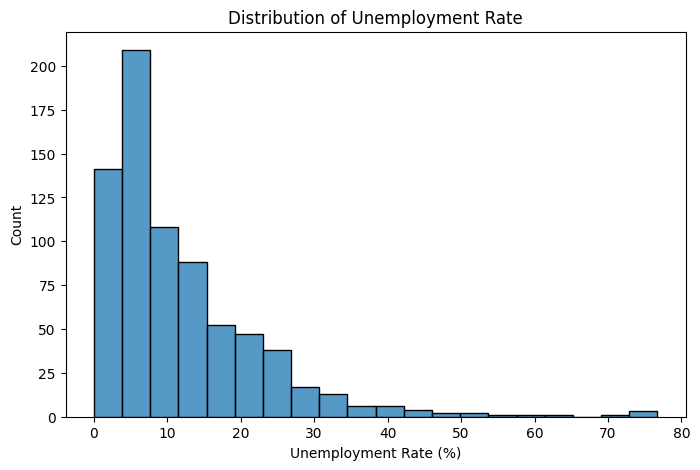

In [32]:

df.columns = df.columns.str.strip()

# Check column name
print(df.columns)

# Plot unemployment distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Estimated Unemployment Rate (%)",
    bins=20
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.show()

# 5.State-wise Average Unemployment

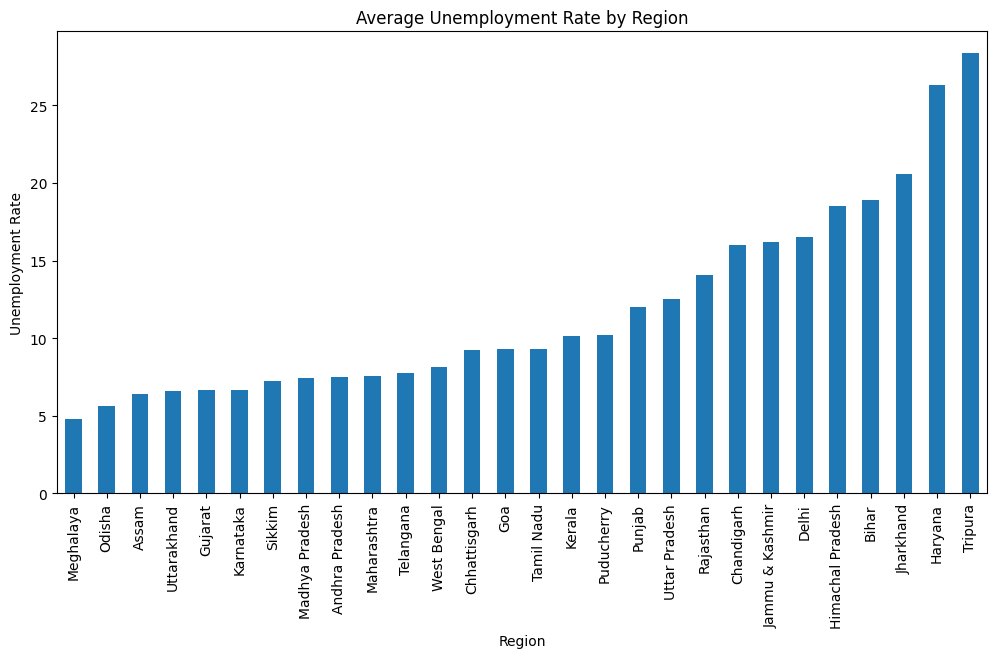

In [33]:
state_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

state_avg.sort_values().plot(kind="bar", figsize=(12,6))

plt.title("Average Unemployment Rate by Region")

plt.ylabel("Unemployment Rate")

plt.show()

# 6.Correlation Heatmap

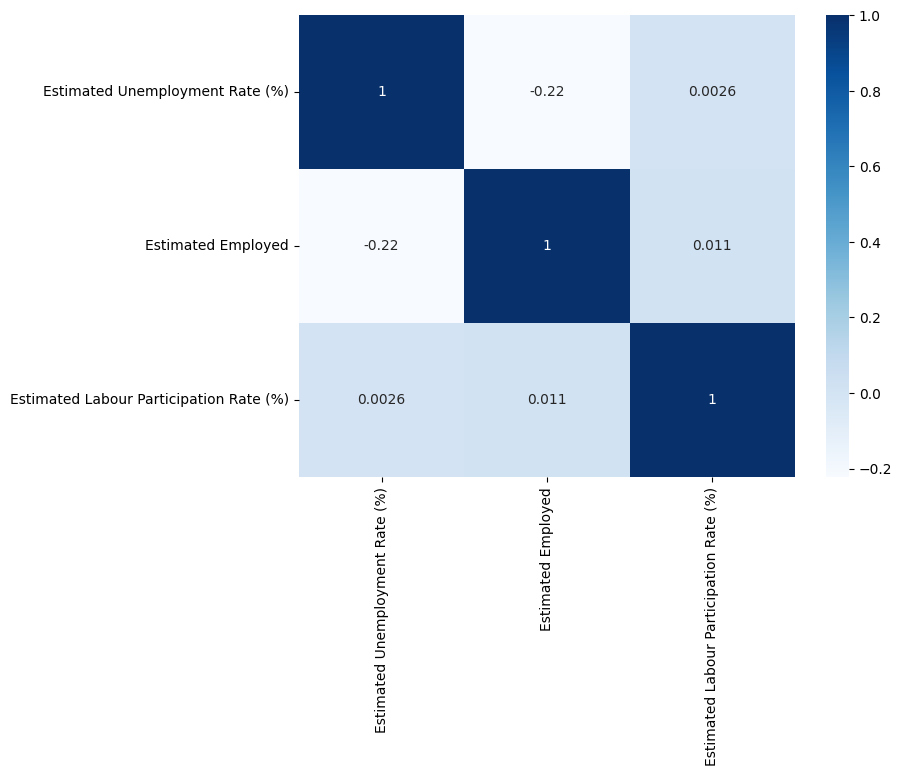

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.show()

# 7.Monthly Trend

### Convert Date column

In [37]:
df["Date"] = pd.to_datetime(df["Date"])

### Monthly average

In [38]:
monthly = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

### plot

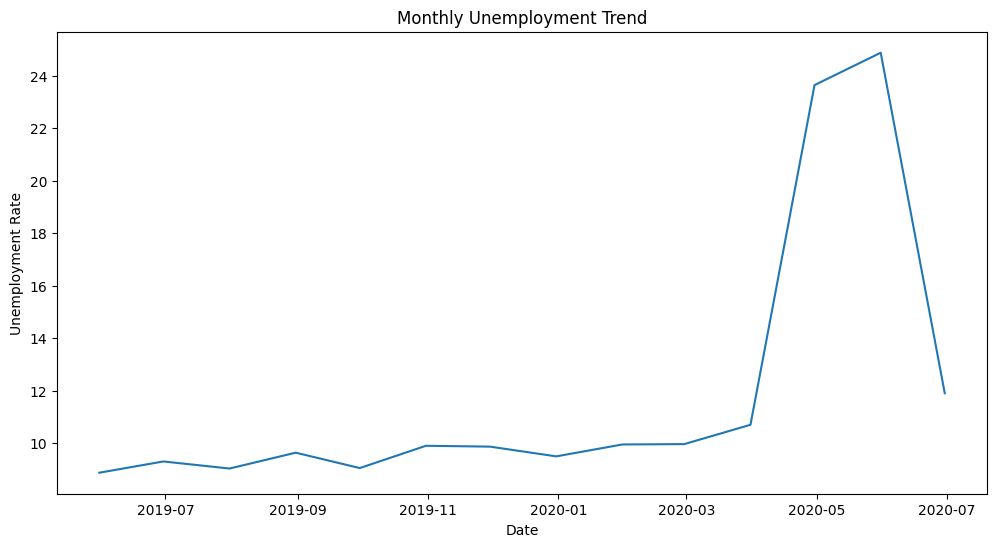

In [39]:
plt.figure(figsize=(12,6))

plt.plot(monthly)

plt.title("Monthly Unemployment Trend")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate")

plt.show()

# 8.COVID-19 Impact

In [40]:
covid = df[df["Date"] >= "2020-03-01"]

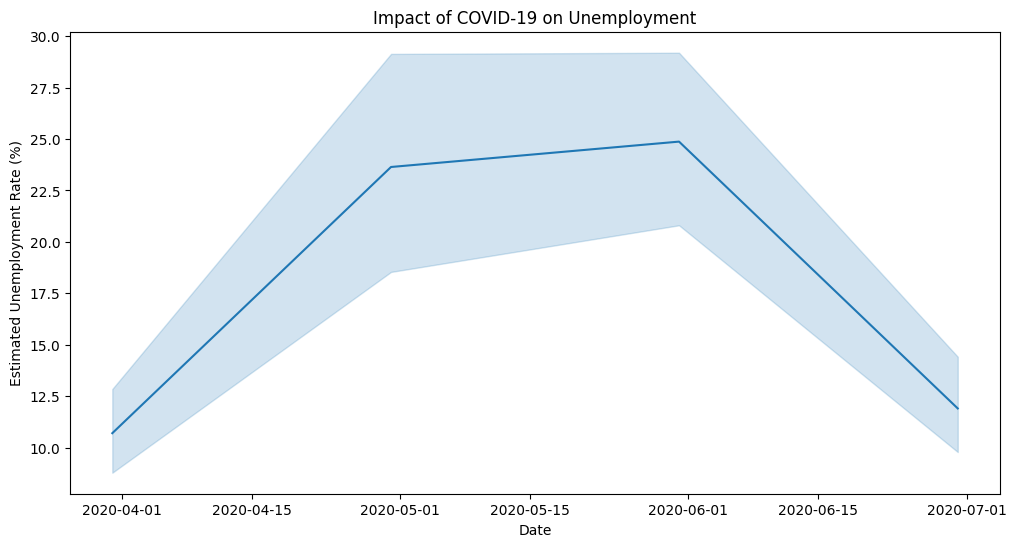

In [41]:
plt.figure(figsize=(12,6))

sns.lineplot(data=covid,
             x="Date",
             y="Estimated Unemployment Rate (%)")

plt.title("Impact of COVID-19 on Unemployment")

plt.show()

# 9.State Comparison

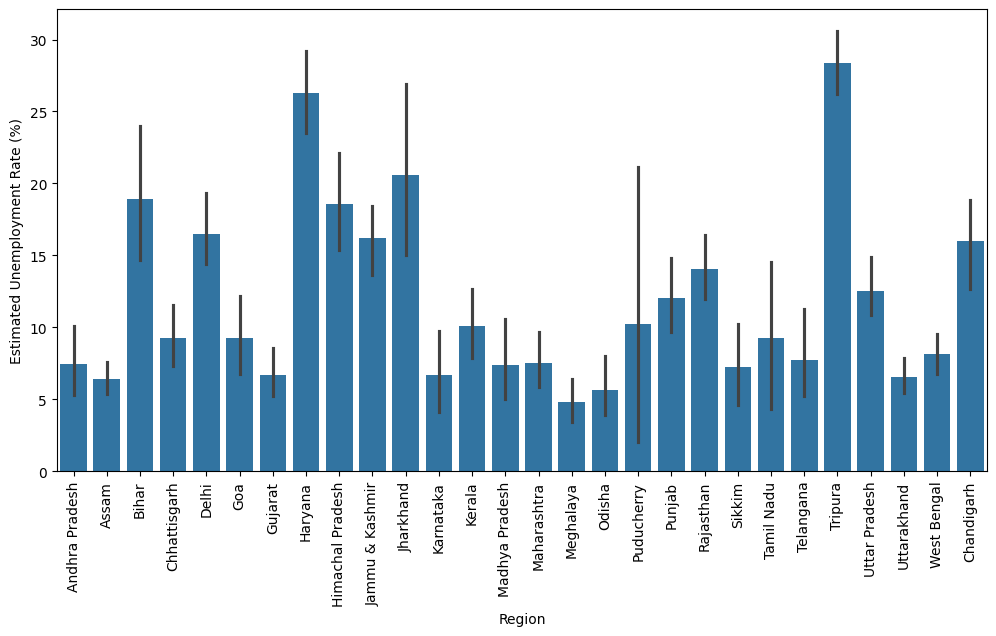

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(data=df,
            x="Region",
            y="Estimated Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

# 10.Pie Chart

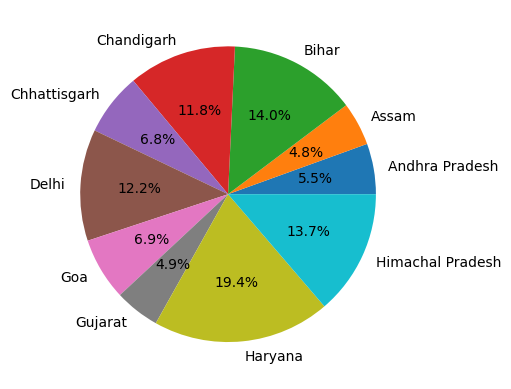

In [43]:
state_avg.head(10).plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.show()

# 11.Insights

#### Unemployment increased significantly during COVID-19.
#### Some states consistently showed higher unemployment rates.
#### The unemployment rate gradually declined after lockdown restrictions eased.
#### Seasonal fluctuations were observed in certain months. 

# 12.Conclusion

#### This project analyzed unemployment trends using Python. Data cleaning, exploratory analysis, and visualizations revealed significant changes in unemployment during the COVID-19 pandemic. The analysis highlights regional differences and demonstrates how data science can support economic decision-making.